# Load the dataset, centroids and models

In [1]:
from datasets import load_from_disk

test_dataset = load_from_disk("../data/test")
test_dataset = test_dataset.select_columns(['text', 'intent'])

ds_texts = test_dataset["text"]
ds_intents = test_dataset["intent"]

In [2]:
import numpy as np
import os

intent_names = [f.replace("_centroid.npy", "") for f in os.listdir("../training/centroids/base")]

base_centroids = {}
finetuned_centroids = {}

for intent in intent_names:
    base_centroids[intent] = np.load(f"../training/centroids/base/{intent}_centroid.npy")
    finetuned_centroids[intent] = np.load(f"../training/centroids/finetuned/{intent}_centroid.npy")

print(f"Loaded {len(base_centroids)} centroids")

Loaded 77 centroids


In [3]:
from sentence_transformers import SentenceTransformer
from peft import PeftModel

base_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cuda")
finetuned_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cuda")
base_transformer = finetuned_model[0].auto_model
peft = PeftModel.from_pretrained(base_transformer, "../training/model")
merged = peft.merge_and_unload()
finetuned_model[0].auto_model = merged

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
base_embeddings = base_model.encode(ds_texts, normalize_embeddings=True, show_progress_bar=True)
finetuned_embeddings = finetuned_model.encode(ds_texts, normalize_embeddings=True, show_progress_bar=True)

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

In [5]:
def compute_inferences(embeddings, centroids, true_labels):
    inferences = []
    centroid_matrix = np.stack(list(centroids.values()))
    centroid_keys = list(centroids.keys())

    for i, embedding in enumerate(embeddings):
        sims = centroid_matrix @ embedding
        predicted = centroid_keys[np.argmax(sims)]
        inferences.append({"real_intent": true_labels[i], "predicted_intent": predicted})

    return inferences

base_inferences = compute_inferences(base_embeddings, base_centroids, ds_intents)
finetuned_inferences = compute_inferences(finetuned_embeddings, finetuned_centroids, ds_intents)

In [6]:
total = len(ds_intents)

base_correct = sum(1 for i in base_inferences if i["real_intent"] == i["predicted_intent"])
ft_correct = sum(1 for i in finetuned_inferences if i["real_intent"] == i["predicted_intent"])

base_accuracy = base_correct / total
ft_accuracy = ft_correct / total

print(f"Base Model Accuracy:      {base_accuracy:.4f} ({base_correct}/{total})")
print(f"Fine-Tuned Accuracy:      {ft_accuracy:.4f} ({ft_correct}/{total})")
print(f"Improvement:              {ft_accuracy - base_accuracy:+.4f}")

Base Model Accuracy:      0.8494 (2616/3080)
Fine-Tuned Accuracy:      0.9172 (2825/3080)
Improvement:              +0.0679


In [7]:
from collections import defaultdict

def per_intent_accuracy(inferences):
    correct = defaultdict(int)
    total = defaultdict(int)
    for inf in inferences:
        total[inf["real_intent"]] += 1
        if inf["real_intent"] == inf["predicted_intent"]:
            correct[inf["real_intent"]] += 1
    return {intent: correct[intent] / total[intent] for intent in sorted(total)}

base_per_intent = per_intent_accuracy(base_inferences)
ft_per_intent = per_intent_accuracy(finetuned_inferences)

print(f"{'Intent':<50} {'Base':>6} {'FT':>6} {'Delta':>7}")
print("-" * 72)
for intent in sorted(base_per_intent):
    b = base_per_intent[intent]
    f = ft_per_intent[intent]
    print(f"{intent:<50} {b:>6.2f} {f:>6.2f} {f - b:>+7.2f}")

Intent                                               Base     FT   Delta
------------------------------------------------------------------------
activate_my_card                                     0.90   0.95   +0.05
age_limit                                            1.00   1.00   +0.00
apple_pay_or_google_pay                              0.95   1.00   +0.05
atm_support                                          0.85   0.97   +0.12
automatic_top_up                                     0.80   0.88   +0.07
balance_not_updated_after_bank_transfer              0.75   0.75   +0.00
balance_not_updated_after_cheque_or_cash_deposit     0.95   0.97   +0.03
beneficiary_not_allowed                              0.47   0.82   +0.35
cancel_transfer                                      0.93   0.95   +0.02
card_about_to_expire                                 1.00   0.97   -0.03
card_acceptance                                      0.95   0.90   -0.05
card_arrival                                       

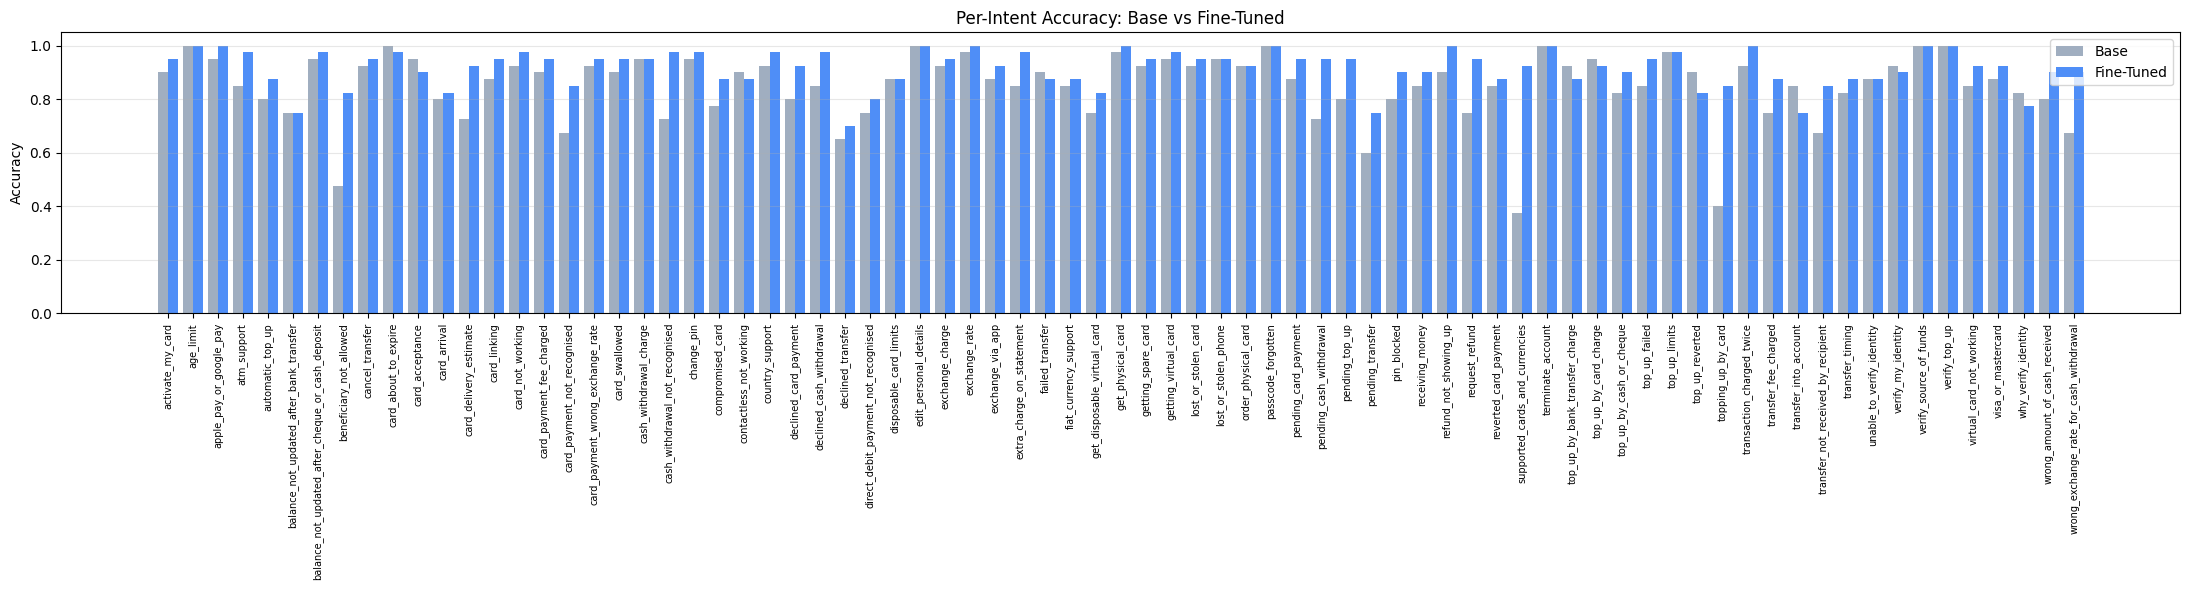

In [8]:
import matplotlib.pyplot as plt
import numpy as np

intents = list(base_per_intent.keys())
base_vals = [base_per_intent[i] for i in intents]
ft_vals = [ft_per_intent[i] for i in intents]

x = np.arange(len(intents))
width = 0.4

fig, ax = plt.subplots(figsize=(22, 6))
ax.bar(x - width/2, base_vals, width, label="Base", color="#a0aec0")
ax.bar(x + width/2, ft_vals, width, label="Fine-Tuned", color="#4f8ef7")

ax.set_xticks(x)
ax.set_xticklabels(intents, rotation=90, fontsize=7)
ax.set_ylabel("Accuracy")
ax.set_title("Per-Intent Accuracy: Base vs Fine-Tuned")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("./figures/per_intent_accuracy.png", dpi=150)
plt.show()